# MICO 알고리즘 교육 실습 노트북

## 학습 순서
```
Part 0 : CMP APC 개요 및 파이프라인 구조
Part 1 : Pre_Thk_VM  (전두께 가상계측)
  1-1  ITM 경로 — BIAS + IQR 필터
  1-2  pre_eq_ch별 Rolling Mean (기간 이동평균)
  1-3  PRE_OPER2~4 회귀 학습
  1-4  실제 웨이퍼 Pre_Thk_VM 최종 산출
  1-5  Detrend 경로 (참고)
Part 2 : Removal Rate (제거율 학습)
  2-1  RR 산출 및 패드 사이클 분리
  2-2  4가지 회귀 모델 비교 (전체/가중/현재/IF)
  2-3  장비별 RR 트렌드
Part 3 : Offset (연마시간 보정값)
  3-1  IDLE 조건 이해
  3-2  IDLE별 OFFSET 학습값 산출
  3-3  시각화
Part 4 : 전체 파이프라인 시뮬레이션
```
> 이 노트북은 **실제 DB 없이 합성 데이터**로 동작합니다.  
> 실제 시스템과 동일한 수식·로직을 사용하므로 알고리즘 이해에 그대로 활용할 수 있습니다.

---
## Part 0 : CMP APC 개요

### 파이프라인 실행 순서
```
merge_df (CMP 실측 데이터)
    │
    ▼
① Pre_Thk_VM   → MA 학습 + PRE_OPER2~4 회귀계수(b1/b0) 저장
    │
    ▼ (Pre_Thk_VM 학습값 로드)
② Removal Rate → RR 회귀계수(b1/b0) 4종 저장
    │               - 전체(b1, b0)
    │               - 가중(b1_weighted, b0_weighted)
    │               - 현재사이클(b1_current, b0_current)
    │               - IF 모델(if_b1, if_b0)
    ▼ (RR 학습값 로드)
③ Offset       → IDLE 조건(Idle_1~4, Layer_1~4)별 보정값 저장
                  ※ 해당 IDLE 조건 wafer에만 적용
    ▼
④ Alarm Check  → N-Sigma 이탈 시 알람
```

### 세 가지 학습값 역할
| 학습값 | 핵심 입력 | 출력 |
|--------|----------|------|
| **Pre_Thk_VM** | ITM 계측값, PRE_OPER2~4 계측값 | pre_eq_ch별 MA + 회귀계수 |
| **Removal Rate** | Pad 마모량, 연마시간 | EQ/Recipe별 b1·b0 (4종) |
| **Offset** | 실측 RR vs 예측 RR | IDLE 조건별 연마시간 보정량 |

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)
print('라이브러리 로드 완료')

라이브러리 로드 완료


In [28]:
# ── 합성 데이터 생성 ─────────────────────────────────────────────────
def make_merge_df(n=800, n_eqp=3, n_pre_eqp=4, seed=42):
    rng = np.random.default_rng(seed)
    start = datetime(2024, 9, 1)
    dates = [start + timedelta(hours=i * 90 * 24 / n) for i in range(n)]

    eqp_ids  = [f'CMP{i+1:02d}' for i in range(n_eqp)]
    recipes  = ['M1_CU_A', 'M1_CU_B']
    pre_eqps = [f'DEP{i+1:02d}' for i in range(n_pre_eqp)]
    pre_chs  = ['A', 'B']

    eqp_assign     = rng.choice(eqp_ids,  n)
    recipe_assign  = rng.choice(recipes,  n)
    pre_eqp_assign = rng.choice(pre_eqps, n)
    pre_ch_assign  = rng.choice(pre_chs,  n)

    # 패드 마모
    pad = np.zeros(n)
    eqp_idx = {e: np.where(eqp_assign == e)[0] for e in eqp_ids}
    for e, idx in eqp_idx.items():
        val, vals = 0.0, []
        reset_pts = sorted(rng.choice(len(idx), size=rng.integers(1, 3), replace=False)) if len(idx) > 3 else []
        for j, i in enumerate(idx):
            if j in reset_pts: val = 0.0
            val += rng.uniform(1.5, 2.5)
            vals.append(val)
        pad[idx] = vals

    true_b1, true_b0 = -0.0003, 3.5
    rr_true  = true_b1 * pad + true_b0 + rng.normal(0, 0.08, n)
    pol_time = np.clip((5500 - 2000) / rr_true + rng.normal(0, 1, n), 800, 1500)

    # 전두께: chamber별 offset + 드리프트
    pre_offset = {(e, c): rng.uniform(-80, 80)   for e in pre_eqps for c in pre_chs}
    pre_drift  = {(e, c): rng.uniform(-0.3, 0.3) for e in pre_eqps for c in pre_chs}
    days = np.array([(d - start).total_seconds() / 86400 for d in dates])
    pre_thk_raw = np.array([
        5500 + pre_offset[(pre_eqp_assign[i], pre_ch_assign[i])]
             + pre_drift [(pre_eqp_assign[i], pre_ch_assign[i])] * days[i]
             + rng.normal(0, 15)
        for i in range(n)
    ])
    post_thk = pre_thk_raw - rr_true * pol_time + rng.normal(0, 10, n)

    # PRE_OPER2~3 계측값: 전공정(증착) 장비에서 측정한 두께 편차
    # 실제 전두께 편차(true_film_dev)와 부분 상관 (b1_true=0.35, 0.20)
    true_film_dev  = pre_thk_raw - 5500
    PRE_OPER2_val  = true_film_dev * 0.35 + rng.normal(0, 4, n)   # 증착 두께 편차
    PRE_OPER3_val  = true_film_dev * 0.20 + rng.normal(0, 5, n)   # 다른 전공정 계측

    # IDLE 조건:
    #   Idle_1~4  : 대기 시간 길이에 따른 구분 (짧음→긺)
    #   Layer_1~4 : 한 Lot 내 레이어(층) 처리 순서에 따른 구분
    #   ''        : Normal (OFFSET 미적용)
    # 비율 → Normal ~50%, Idle_1~4 각 ~6%, Layer_1~4 각 ~3%
    idle_pool = ([''] * 8
                 + ['Idle_1',  'Idle_2',  'Idle_3',  'Idle_4']
                 + ['Layer_1', 'Layer_2', 'Layer_3', 'Layer_4'])
    idle = rng.choice(idle_pool, n)

    pre_oper_time  = [d - timedelta(hours=rng.uniform(1, 6)) for d in dates]
    pre_eq_ch_list = [f'{e}_{c}' for e, c in zip(pre_eqp_assign, pre_ch_assign)]

    df = pd.DataFrame({
        'Date'          : dates,
        'eqp_id'        : eqp_assign,
        'recipe_id'     : recipe_assign,
        'eqp_model'     : 'AMAT_REFLEXION',
        'lot_id'        : [f'LOT{i//25:04d}' for i in range(n)],
        'substrate_id'  : [f'W{i:05d}' for i in range(n)],
        'pre_eqp_id'    : pre_eqp_assign,
        'pre_eqp_ch'    : pre_ch_assign,
        'pre_oper_time' : pre_oper_time,
        'Cu_THK'        : post_thk,
        'TIME_Para'     : pol_time,
        'Pad_Para'      : pad,
        'Head_Para'     : pad * 0.8 + rng.uniform(0, 50, n),
        'IDLE'          : idle,
        'Pre_THK_ITM'   : pre_thk_raw + rng.normal(0, 5, n),
        'pre_eq_ch'     : pre_eq_ch_list,
        'PRE_OPER2_val' : PRE_OPER2_val,
        'PRE_OPER3_val' : PRE_OPER3_val,
        '_true_pre_thk' : pre_thk_raw,
        '_true_rr'      : rr_true,
        '_true_film_dev': true_film_dev,
    })
    df['Date']          = pd.to_datetime(df['Date'])
    df['pre_oper_time'] = pd.to_datetime(df['pre_oper_time'])
    return df.sort_values('Date').reset_index(drop=True)


merge_df = make_merge_df(n=800)

print(f'합성 데이터: {len(merge_df)}행  ({merge_df["Date"].min().date()} ~ {merge_df["Date"].max().date()})')
print(f'장비: {sorted(merge_df["eqp_id"].unique())}')
print(f'\nIDLE 조건 분포:')
idle_vc = merge_df['IDLE'].replace('', 'Normal').value_counts().sort_index()
for k, v in idle_vc.items():
    print(f'  {k:8s}: {v}건 ({v/len(merge_df)*100:.1f}%)')
merge_df[['Date','eqp_id','pre_eq_ch','Cu_THK','IDLE','PRE_OPER2_val','PRE_OPER3_val']].head(4)

합성 데이터: 800행  (2024-09-01 ~ 2024-11-29)
장비: ['CMP01', 'CMP02', 'CMP03']

IDLE 조건 분포:
  Idle_1  : 58건 (7.2%)
  Idle_2  : 54건 (6.8%)
  Idle_3  : 49건 (6.1%)
  Idle_4  : 59건 (7.4%)
  Layer_1 : 42건 (5.2%)
  Layer_2 : 36건 (4.5%)
  Layer_3 : 55건 (6.9%)
  Layer_4 : 50건 (6.2%)
  Normal  : 397건 (49.6%)


,Date,eqp_id,pre_eq_ch,Cu_THK,IDLE,PRE_OPER2_val,PRE_OPER3_val
0,2024-09-01 00:00:00,CMP01,DEP02_A,2037.361833,Idle_4,7.532537,11.910967
1,2024-09-01 02:42:00,CMP03,DEP03_B,1988.704063,,-2.098798,-0.052750
2,2024-09-01 05:24:00,CMP02,DEP04_B,2019.872344,Idle_2,18.140358,21.753144
3,2024-09-01 08:06:00,CMP02,DEP02_B,2072.957825,,20.146705,12.834643


---
## Part 1 : Pre_Thk_VM (전두께 가상계측)

### 개념
CMP 투입 전 전두께는 전공정 장비(chamber)마다 편차가 있습니다.  
Pre_Thk_VM은 이 편차를 학습하여 APC 파라미터 계산 시 보정값으로 사용합니다.

### 최종 Pre_Thk_VM 산출 공식
```
Pre_Thk_VM = Pre_Thk_MA (기간 이동평균)
           + PRE_OPER2_b1 × PRE_OPER2_측정값 + PRE_OPER2_b0
           + PRE_OPER3_b1 × PRE_OPER3_측정값 + PRE_OPER3_b0
           + PRE_OPER4_b1 × PRE_OPER4_측정값 + PRE_OPER4_b0  (설정된 경우)
```
- **Pre_Thk_MA** : pre_eq_ch 기준 N일 Rolling Mean (chamber 편차)
- **PRE_OPER 회귀** : 전공정 계측값으로 설명되는 추가 편차

### 1-1 : BIAS 산출 및 IQR 필터 (ITM 경로)

IQR 필터: 800행 → 800행  (제거 0건)


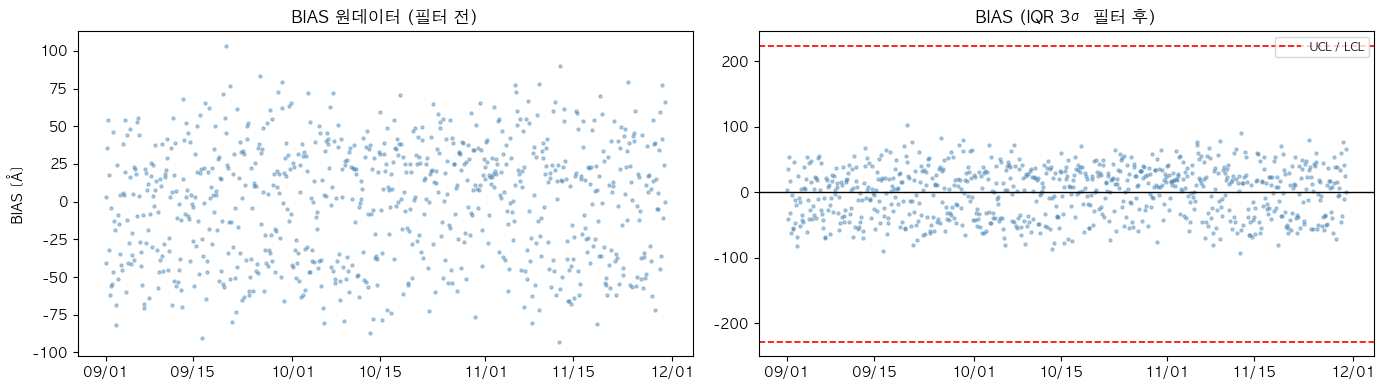

In [29]:
def iqr_filter(df, col, sigma=3):
    q1, q3 = df[col].quantile([0.25, 0.75])
    IQR    = q3 - q1
    return df[(df[col] >= q1 - sigma*IQR) & (df[col] <= q3 + sigma*IQR)].copy()


df_itm = merge_df.copy()
df_itm['BIAS'] = df_itm['Pre_THK_ITM'] - df_itm['Pre_THK_ITM'].mean()

n_before = len(df_itm)
df_itm   = iqr_filter(df_itm, 'BIAS', sigma=3)
print(f'IQR 필터: {n_before}행 → {len(df_itm)}행  (제거 {n_before - len(df_itm)}건)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
q1, q3 = merge_df['BIAS'].quantile([0.25, 0.75]) if 'BIAS' in merge_df else df_itm['BIAS'].quantile([0.25, 0.75])
q1, q3 = df_itm['BIAS'].quantile([0.25, 0.75])
IQR = q3 - q1

axes[0].scatter(merge_df['Date'], merge_df['Pre_THK_ITM'] - merge_df['Pre_THK_ITM'].mean(),
                s=5, alpha=0.4, color='steelblue')
axes[0].set_title('BIAS 원데이터 (필터 전)')
axes[0].set_ylabel('BIAS [Å]')

axes[1].scatter(df_itm['Date'], df_itm['BIAS'], s=5, alpha=0.4, color='steelblue')
axes[1].axhline(q3 + 3*IQR, color='red', lw=1.2, linestyle='--', label='UCL / LCL')
axes[1].axhline(q1 - 3*IQR, color='red', lw=1.2, linestyle='--')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('BIAS (IQR 3σ 필터 후)')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.tight_layout()
plt.show()

### 1-2 : pre_eq_ch별 Rolling Mean — Pre_Thk_MA 산출

=== Pre_Thk_MA (chamber별 이동평균) ===
pre_eq_ch  Pre_Thk  Pre_Thk_Count
  DEP01_A   -43.87           34.0
  DEP01_B   -50.70           37.0
  DEP02_A    32.76           37.0
  DEP02_B    53.52           37.0
  DEP03_A    20.68           35.0
  DEP03_B     9.77           23.0
  DEP04_A   -23.07           33.0
  DEP04_B    17.80           35.0


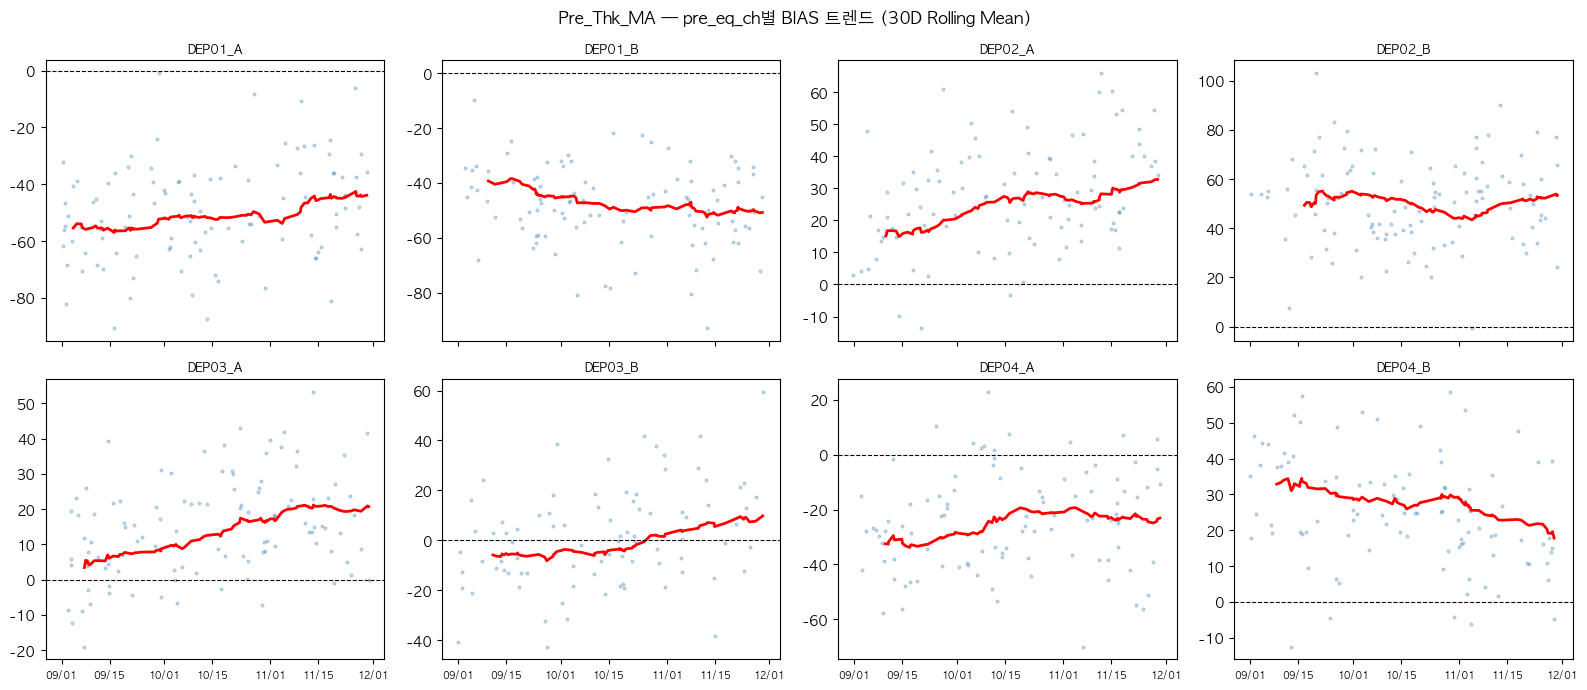

In [30]:
# ── pre_eq_ch별 Rolling Mean ─────────────────────────────────────────
# 실제 코드: PRE_THK_VM_Get.rolling_mean()
def rolling_mean_by_ch(df, value_col, period='30D', min_count=10):
    df = df.copy()
    df['pre_oper_time'] = pd.to_datetime(df['pre_oper_time'])
    df.sort_values('pre_oper_time', inplace=True)
    rolls, cnts = [], []
    for ch in df['pre_eq_ch'].unique():
        sub    = df[df['pre_eq_ch'] == ch][[value_col, 'pre_oper_time']]
        rolled = sub.rolling(window=period, on='pre_oper_time', min_periods=min_count).mean()[value_col]
        count  = sub.rolling(window=period, on='pre_oper_time', min_periods=min_count).count()[value_col]
        rolls.append(rolled)
        cnts.append(count)
    df['Pre_Thk']       = pd.concat(rolls)
    df['Pre_Thk_Count'] = pd.concat(cnts)
    return df


df_rolled = rolling_mean_by_ch(df_itm, 'BIAS', period='30D', min_count=10)

# pre_eq_ch별 최신 MA 값
pre_thk_ma = (
    df_rolled.dropna(subset=['Pre_Thk'])
    .sort_values('pre_oper_time')
    .groupby('pre_eq_ch')
    .last()[['Pre_Thk', 'Pre_Thk_Count']]
    .reset_index()
)
print('=== Pre_Thk_MA (chamber별 이동평균) ===')
print(pre_thk_ma.round(2).to_string(index=False))

# 시각화
channels = sorted(df_rolled['pre_eq_ch'].unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
axes = axes.flatten()
for i, ch in enumerate(channels):
    s = df_rolled[df_rolled['pre_eq_ch'] == ch].sort_values('pre_oper_time')
    axes[i].scatter(s['pre_oper_time'], s['BIAS'],     s=4,  alpha=0.3, color='steelblue')
    axes[i].plot(   s['pre_oper_time'], s['Pre_Thk'],  lw=2, color='red', label='MA')
    axes[i].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[i].set_title(ch, fontsize=9)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    axes[i].tick_params(axis='x', labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Pre_Thk_MA — pre_eq_ch별 BIAS 트렌드 (30D Rolling Mean)', fontsize=12)
plt.tight_layout()
plt.show()

### 1-3 : PRE_OPER2~4 회귀 학습

Rolling Mean 만으로는 설명되지 않는 전공정 편차를 추가 회귀로 보정합니다.

```
학습 데이터:
  X = PRE_OPER2 계측값  (전전공정 두께 편차)
  y = BIAS              (0-centered, MA 제거 전 값으로 회귀)

회귀식:  BIAS ≈ PRE_OPER2_b1 × X + PRE_OPER2_b0

저장 결과 (pre_thk_table에 추가):
  PRE_OPER2_b1, PRE_OPER2_b0
  PRE_OPER3_b1, PRE_OPER3_b0  (설정 시)
  PRE_OPER4_b1, PRE_OPER4_b0  (설정 시)
```

실제 코드: `PRE_THK_VM_Get.fit_pre_oper_regression()`

  PRE_OPER2: b1=+2.6125  b0=-18.7764  R²=0.8966
  PRE_OPER3: b1=+3.5190  b0=-14.4776  R²=0.6878

실제 설정값: PRE_OPER2_b1_true=0.35, PRE_OPER3_b1_true=0.20


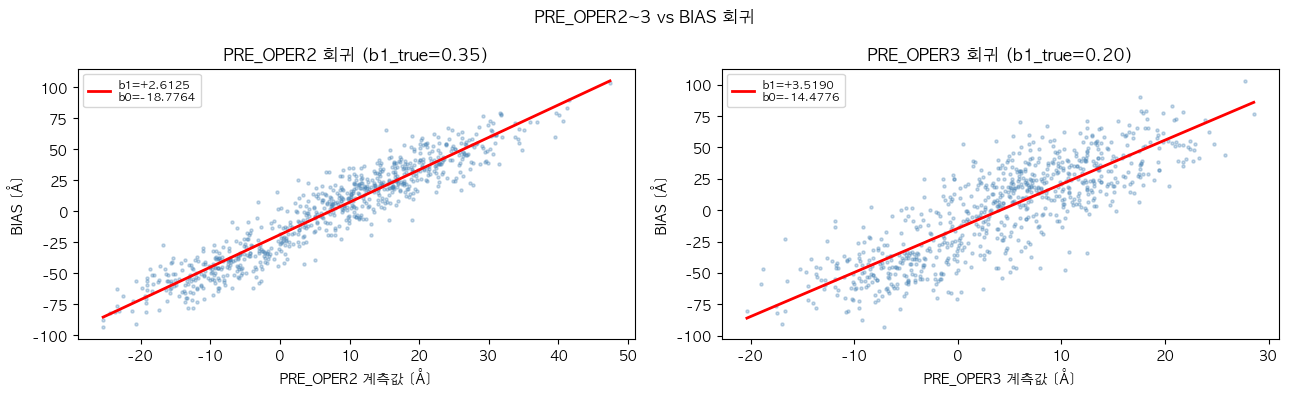

In [31]:
# ── PRE_OPER2~4 회귀 학습 ────────────────────────────────────────────
# 실제 코드: PRE_THK_VM_Get.fit_pre_oper_regression()

lr = LinearRegression()
oper_coef_table = []

oper_pairs = [
    ('PRE_OPER2_val', 'PRE_OPER2'),
    ('PRE_OPER3_val', 'PRE_OPER3'),
]

# df_itm은 merge_df.copy()이므로 PRE_OPER2_val, PRE_OPER3_val 이미 포함
# (별도 merge 불필요 — 다시 merge 하면 _x/_y suffix 충돌)
train_df = df_itm.copy()

for col, prefix in oper_pairs:
    fit_df = train_df[['BIAS', col]].dropna()
    lr.fit(fit_df[[col]], fit_df[['BIAS']])
    b1 = round(lr.coef_[0][0],  4)
    b0 = round(lr.intercept_[0], 4)
    r2 = round(lr.score(fit_df[[col]], fit_df[['BIAS']]), 4)
    oper_coef_table.append({'PRE_OPER': prefix, 'b1': b1, 'b0': b0, 'R²': r2})
    print(f'  {prefix}: b1={b1:+.4f}  b0={b0:+.4f}  R²={r2:.4f}')

oper_coef_df = pd.DataFrame(oper_coef_table)
b1_oper2, b0_oper2 = oper_coef_df[oper_coef_df['PRE_OPER']=='PRE_OPER2'][['b1','b0']].values[0]
b1_oper3, b0_oper3 = oper_coef_df[oper_coef_df['PRE_OPER']=='PRE_OPER3'][['b1','b0']].values[0]

print(f'\n실제 설정값: PRE_OPER2_b1_true=0.35, PRE_OPER3_b1_true=0.20')

# ── 시각화: BIAS vs PRE_OPER 산점도 + 회귀선 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_i, (col, prefix, b1, b0) in enumerate([
    ('PRE_OPER2_val', 'PRE_OPER2', b1_oper2, b0_oper2),
    ('PRE_OPER3_val', 'PRE_OPER3', b1_oper3, b0_oper3),
]):
    fit_df = train_df[['BIAS', col]].dropna()
    ax = axes[ax_i]
    ax.scatter(fit_df[col], fit_df['BIAS'], s=5, alpha=0.3, color='steelblue')
    x_rng = np.linspace(fit_df[col].min(), fit_df[col].max(), 100)
    ax.plot(x_rng, b1*x_rng + b0, lw=2, color='red', label=f'b1={b1:+.4f}\nb0={b0:+.4f}')
    ax.set_xlabel(f'{prefix} 계측값 [Å]')
    ax.set_ylabel('BIAS [Å]')
    ax.set_title(f'{prefix} 회귀 (b1_true={[0.35, 0.20][ax_i]:.2f})')
    ax.legend(fontsize=8)

plt.suptitle('PRE_OPER2~3 vs BIAS 회귀', fontsize=12)
plt.tight_layout()
plt.show()

### 1-4 : 실제 웨이퍼 Pre_Thk_VM 최종 산출

새 웨이퍼가 CMP 장비에 투입될 때, 해당 웨이퍼의 Pre_Thk_VM을 이렇게 계산합니다:

```python
# 1단계: pre_eq_ch 조회 → 해당 chamber의 Pre_Thk_MA 가져오기
Pre_Thk_MA = pre_thk_ma_table[wafer.pre_eq_ch]

# 2단계: PRE_OPER 계측값으로 추가 보정
Correction  = b1_oper2 × wafer.PRE_OPER2_실측 + b0_oper2
            + b1_oper3 × wafer.PRE_OPER3_실측 + b0_oper3

# 3단계: 최종 Pre_Thk_VM
Pre_Thk_VM = Pre_Thk_MA + Correction
```

실제 코드: `Removal_Rate_Get.load_pre_thk_data()` 내부에서 적용

=== PRE_OPER 회귀 보정 효과 ===
  Pre_Thk_MA만  → 상관계수=0.9062  RMSE=23.70 Å
  Pre_Thk_VM    → 상관계수=0.9678  RMSE=63.42 Å  (PRE_OPER 보정 후)

=== 웨이퍼별 Pre_Thk_VM 산출 예시 ===
substrate_id pre_eq_ch  Pre_Thk_MA  PRE_OPER2_corr  PRE_OPER3_corr  Pre_Thk_VM
      W00008   DEP01_A      -43.87          -61.41          -31.43     -136.71
      W00175   DEP01_A      -43.87          -24.45          -30.66      -98.98
      W00510   DEP02_A       32.76           17.51           27.25       77.52
      W00084   DEP02_A       32.76           14.25           11.94       58.96
      W00642   DEP02_A       32.76           71.00           34.19      137.95
      W00735   DEP03_A       20.68           39.87           19.41       79.96
      W00540   DEP03_B        9.77            4.45           50.16       64.38
      W00430   DEP03_B        9.77          -31.31           13.74       -7.79
      W00242   DEP04_A      -23.07          -14.26          -33.78      -71.11
      W00764   DEP04_A      -23.07          -66.0

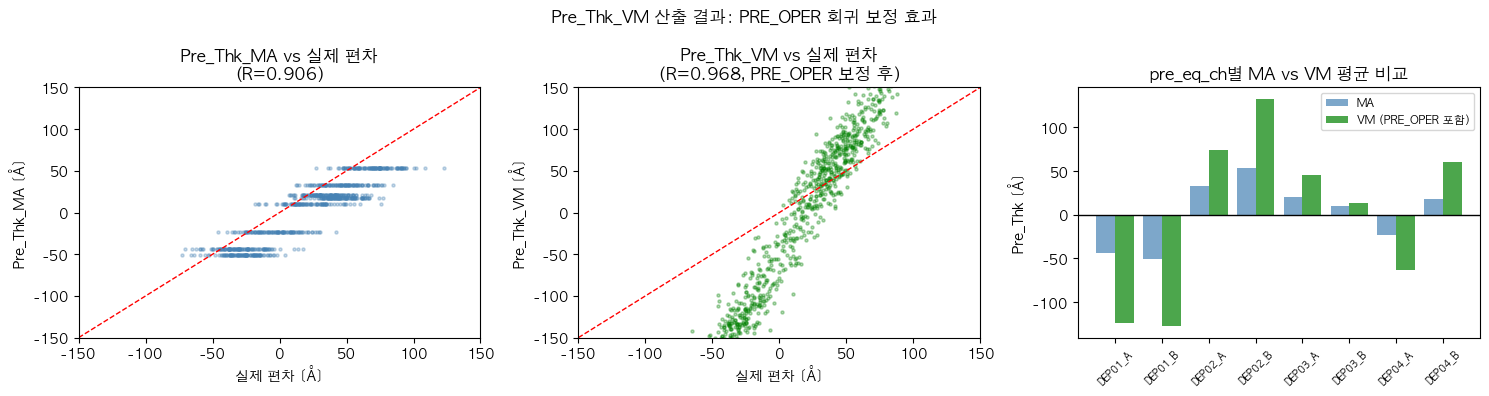

In [32]:
# ── 실제 웨이퍼 Pre_Thk_VM 산출 ──────────────────────────────────────
infer_df = merge_df.copy()

# Step 1: pre_eq_ch → Pre_Thk_MA 매핑
ma_map = pre_thk_ma.set_index('pre_eq_ch')['Pre_Thk'].to_dict()
infer_df['Pre_Thk_MA'] = infer_df['pre_eq_ch'].map(ma_map).fillna(0)

# Step 2: PRE_OPER 회귀 보정
infer_df['PRE_OPER2_corr'] = b1_oper2 * infer_df['PRE_OPER2_val'] + b0_oper2
infer_df['PRE_OPER3_corr'] = b1_oper3 * infer_df['PRE_OPER3_val'] + b0_oper3

# Step 3: 최종 Pre_Thk_VM
infer_df['Pre_Thk_VM'] = infer_df['Pre_Thk_MA'] + infer_df['PRE_OPER2_corr'] + infer_df['PRE_OPER3_corr']

# 검증: Pre_Thk_VM vs 실제 전두께 편차
infer_df['_true_bias'] = infer_df['_true_film_dev']  # 실제 편차 (검증용)
corr_ma  = infer_df[['Pre_Thk_MA',   '_true_bias']].dropna().corr().iloc[0, 1]
corr_vm  = infer_df[['Pre_Thk_VM',   '_true_bias']].dropna().corr().iloc[0, 1]
rmse_ma  = np.sqrt(((infer_df['Pre_Thk_MA']  - infer_df['_true_bias'])**2).mean())
rmse_vm  = np.sqrt(((infer_df['Pre_Thk_VM']  - infer_df['_true_bias'])**2).mean())

print('=== PRE_OPER 회귀 보정 효과 ===')
print(f'  Pre_Thk_MA만  → 상관계수={corr_ma:.4f}  RMSE={rmse_ma:.2f} Å')
print(f'  Pre_Thk_VM    → 상관계수={corr_vm:.4f}  RMSE={rmse_vm:.2f} Å  (PRE_OPER 보정 후)')

# 샘플 wafer 10개 출력
print('\n=== 웨이퍼별 Pre_Thk_VM 산출 예시 ===')
sample = infer_df.sample(10, random_state=1)[[
    'substrate_id', 'pre_eq_ch', 'Pre_Thk_MA', 'PRE_OPER2_corr', 'PRE_OPER3_corr', 'Pre_Thk_VM'
]].sort_values('pre_eq_ch')
print(sample.round(2).to_string(index=False))

# ── 시각화 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MA vs 실제 편차
axes[0].scatter(infer_df['_true_bias'], infer_df['Pre_Thk_MA'], s=5, alpha=0.3, color='steelblue')
lim = (-150, 150)
axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_title(f'Pre_Thk_MA vs 실제 편차\n(R={corr_ma:.3f})')
axes[0].set_xlabel('실제 편차 [Å]'); axes[0].set_ylabel('Pre_Thk_MA [Å]')

# VM vs 실제 편차
axes[1].scatter(infer_df['_true_bias'], infer_df['Pre_Thk_VM'], s=5, alpha=0.3, color='green')
axes[1].plot(lim, lim, 'r--', lw=1)
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_title(f'Pre_Thk_VM vs 실제 편차\n(R={corr_vm:.3f}, PRE_OPER 보정 후)')
axes[1].set_xlabel('실제 편차 [Å]'); axes[1].set_ylabel('Pre_Thk_VM [Å]')

# pre_eq_ch별 MA / VM 비교 막대
bar_data = pre_thk_ma.copy()
bar_data['Pre_Thk_VM_avg'] = bar_data['pre_eq_ch'].map(
    infer_df.groupby('pre_eq_ch')['Pre_Thk_VM'].mean().to_dict()
)
x = np.arange(len(bar_data))
axes[2].bar(x - 0.2, bar_data['Pre_Thk'], 0.4, label='MA', color='steelblue', alpha=0.7)
axes[2].bar(x + 0.2, bar_data['Pre_Thk_VM_avg'], 0.4, label='VM (PRE_OPER 포함)', color='green', alpha=0.7)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xticks(x); axes[2].set_xticklabels(bar_data['pre_eq_ch'], rotation=45, fontsize=7)
axes[2].set_title('pre_eq_ch별 MA vs VM 평균 비교')
axes[2].set_ylabel('Pre_Thk [Å]')
axes[2].legend(fontsize=8)

plt.suptitle('Pre_Thk_VM 산출 결과: PRE_OPER 회귀 보정 효과', fontsize=12)
plt.tight_layout()
plt.show()

### 1-5 : Detrend 경로 (참고)

ITM 계측기가 없는 경우 CMP 실측 데이터로 전두께를 역산합니다.

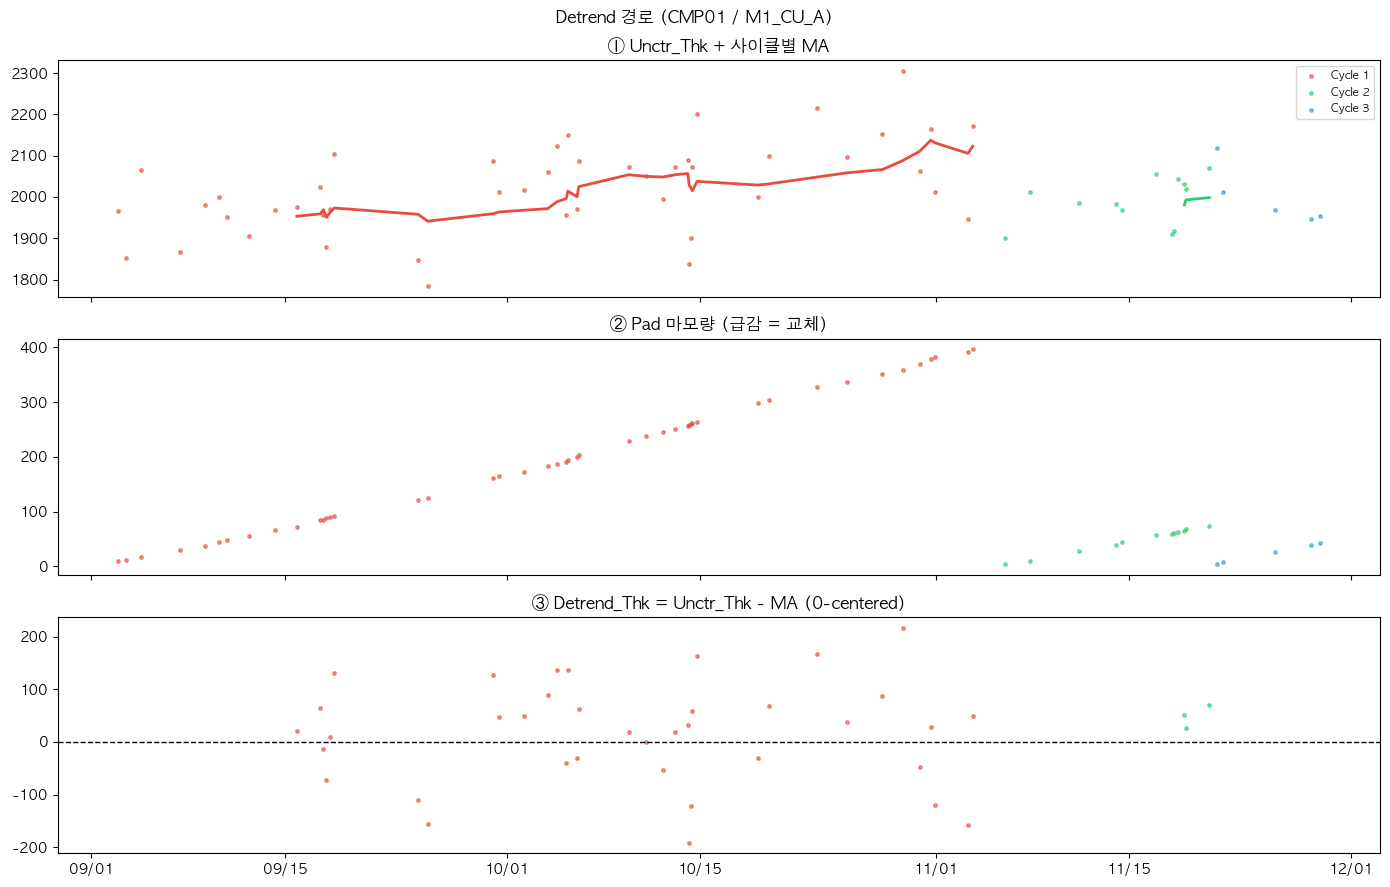

In [33]:
# ── Detrend 경로 ─────────────────────────────────────────────────────
Pre_Target  = 5500.0
Post_Target = 2000.0
pol_para    = ['TIME_Para']
FIX_Time    = merge_df['TIME_Para'].mean()

sub = merge_df[
    (merge_df['eqp_id'] == 'CMP01') & (merge_df['recipe_id'] == 'M1_CU_A') &
    ((merge_df['IDLE'] == '') | merge_df['IDLE'].isna())
].copy().sort_values('Date').reset_index(drop=True)

sub['Pol_Time']   = sub[pol_para].sum(axis=1)
sub['RR']         = (Pre_Target - sub['Cu_THK']) / sub['Pol_Time']
sub['Unctr_Thk']  = Pre_Target - (sub['RR'] * FIX_Time)
sub['pad_cycle']  = (sub['Pad_Para'].diff() < -0.5).cumsum() + 1

for _, grp in sub.groupby('pad_cycle'):
    sub.loc[grp.index, 'Unctr_Thk_MA'] = grp['Unctr_Thk'].rolling(10).mean().values
sub['Detrend_Thk'] = sub['Unctr_Thk'] - sub['Unctr_Thk_MA']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colors = ['#e74c3c', '#2ecc71', '#3498db']
for cycle in sub['pad_cycle'].unique():
    c = colors[(cycle - 1) % 3]
    s = sub[sub['pad_cycle'] == cycle]
    axes[0].scatter(s['Date'], s['Unctr_Thk'], s=6, color=c, alpha=0.6, label=f'Cycle {cycle}')
    axes[0].plot(s['Date'], s['Unctr_Thk_MA'], lw=2, color=c)
    axes[1].scatter(s['Date'], s['Pad_Para'],   s=6, color=c, alpha=0.6)
    axes[2].scatter(s['Date'], s['Detrend_Thk'],s=6, color=c, alpha=0.6)

axes[0].set_title('① Unctr_Thk + 사이클별 MA'); axes[0].legend(fontsize=8)
axes[1].set_title('② Pad 마모량 (급감 = 교체)')
axes[2].axhline(0, color='black', lw=1, linestyle='--')
axes[2].set_title('③ Detrend_Thk = Unctr_Thk - MA (0-centered)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
fig.suptitle('Detrend 경로 (CMP01 / M1_CU_A)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 2 : Removal Rate (제거율 학습)

### 개념
$$RR = \frac{(Pre\_Target + Pre\_Thk\_VM) - Post\_Thk}{Pol\_Time}$$

패드 마모량에 따른 RR 변화를 4가지 모델로 학습합니다:

| 모델 | 학습 범위 | 사용 목적 |
|------|----------|----------|
| `b1, b0` | 전체 구간 회귀 | 기본 예측 |
| `b1_weighted, b0_weighted` | 최근 가중 회귀 (최근 구간 `RR_Weight`배) | 최근 경향 반영 |
| `b1_current, b0_current` | 현재 사이클만 | 최신 패드 특성 |
| `if_b1, if_b0` | Pad_Para ≤ Pad_Seperation 초기 구간 | 패드 초기 비선형 보정 |

In [34]:
# ── Pre_Thk_VM 적용 + RR 산출 ──────────────────────────────────────
merge_df_rr = merge_df.copy()
merge_df_rr['Pre_Thk_VM'] = infer_df['Pre_Thk_VM'].values
merge_df_rr['Pre_Thk_corrected'] = Pre_Target + merge_df_rr['Pre_Thk_VM']
merge_df_rr['Pol_Time'] = merge_df_rr[pol_para].sum(axis=1)
merge_df_rr['RR'] = (merge_df_rr['Pre_Thk_corrected'] - merge_df_rr['Cu_THK']) / merge_df_rr['Pol_Time']

rr_mean, rr_std = merge_df_rr['RR'].mean(), merge_df_rr['RR'].std()
merge_df_rr = merge_df_rr[
    (merge_df_rr['RR'] > rr_mean - 6*rr_std) & (merge_df_rr['RR'] < rr_mean + 6*rr_std)
].copy()

# 패드 사이클 분리
def detect_cycles(df, consumable, threshold=-3):
    df = df.copy()
    df['eq_recipe'] = df['eqp_id'] + '//' + df['recipe_id']
    result = []
    for eq_rcp in df['eq_recipe'].unique():
        eqp, rcp = eq_rcp.split('//')
        s = df[(df['eqp_id']==eqp) & (df['recipe_id']==rcp)].sort_values('Date').reset_index(drop=True)
        raw = (s[consumable].diff() < threshold).cumsum()
        s['cycle'] = raw.max() + 1 - raw
        result.append(s)
    return pd.concat(result)

merge_df_rr = detect_cycles(merge_df_rr, 'Pad_Para')
print(f'RR 데이터: {len(merge_df_rr)}행')
print(merge_df_rr.groupby(['eqp_id', 'recipe_id'])['cycle'].agg(['min','max','nunique'])
      .rename(columns={'min':'최소사이클','max':'최대사이클','nunique':'사이클수'}))

RR 데이터: 800행
                  최소사이클  최대사이클  사이클수
eqp_id recipe_id                    
CMP01  M1_CU_A        1      3     3
       M1_CU_B        1      3     3
CMP02  M1_CU_A        1      2     2
       M1_CU_B        1      2     2
CMP03  M1_CU_A        1      2     2
       M1_CU_B        1      2     2


### 2-2 : 4가지 회귀 모델 — 모델별 b1/b0 비교

In [35]:
# ── 4가지 모델 산출 + 모델별 비교 테이블 ────────────────────────────────
RR_Weight      = 5
RR_Count       = 10
Pad_Seperation = 500
consumable     = 'Pad_Para'

lr  = LinearRegression()
rr_model_rows = []   # 결과 저장

for eqp in sorted(merge_df_rr['eqp_id'].unique()):
    for rcp in sorted(merge_df_rr['recipe_id'].unique()):
        data = merge_df_rr[
            (merge_df_rr['eqp_id'] == eqp) & (merge_df_rr['recipe_id'] == rcp)
        ].copy().sort_values('Date').reset_index(drop=True)

        if len(data) < 10:
            continue

        row = {'EQ': eqp, 'Recipe': rcp, 'Count': len(data)}

        # ① 전체 회귀
        lr.fit(data[[consumable]], data[['RR']])
        row['b1'], row['b0'] = round(lr.coef_[0][0], 4), round(lr.intercept_[0], 4)

        # ② 가중 회귀
        data['date_g'] = pd.cut(data['Date'], bins=5, labels=False)
        wmap = {0:1, 1:2, 2:3, 3:4, 4:RR_Weight}
        rw   = data['date_g'].map(wmap).astype(int)
        Xw   = np.repeat(data[consumable].values, rw).reshape(-1, 1)
        yw   = np.repeat(data['RR'].values, rw)
        lr.fit(Xw, yw)
        row['b1_weighted'], row['b0_weighted'] = round(lr.coef_[0], 4), round(lr.intercept_, 4)

        # ③ 현재 사이클 회귀
        current = data[data['cycle'] == 1]
        if len(current) >= RR_Count:
            lr.fit(current[[consumable]], current[['RR']])
            row['b1_current'] = round(lr.coef_[0][0], 4)
            row['b0_current'] = round(lr.intercept_[0], 4)
        else:
            row['b1_current'] = row['b0_current'] = None

        # ④ IF 모델
        if_data = data[data[consumable] <= Pad_Seperation]
        step = Pad_Seperation / 4
        if len(if_data) >= 100:
            if_cnt = pd.cut(if_data[consumable],
                            bins=[0, step, step*2, step*3, Pad_Seperation],
                            labels=['Q1','Q2','Q3','Q4']).value_counts()
            if (if_cnt >= 25).all():
                lr.fit(if_data[[consumable]], if_data[['RR']])
                row['if_b1'] = round(lr.coef_[0][0], 4)
                row['if_b0'] = round(lr.intercept_[0], 4)
            else:
                row['if_b1'] = row['if_b0'] = None
        else:
            row['if_b1'] = row['if_b0'] = None

        rr_model_rows.append(row)

rr_model_df = pd.DataFrame(rr_model_rows)

# ── 모델별 b1 / b0 비교 테이블 출력 ──────────────────────────────────
print('=== Removal Rate 학습값 — 4가지 모델 비교 ===')
display_cols = ['EQ', 'Recipe', 'Count',
                'b1', 'b0',
                'b1_weighted', 'b0_weighted',
                'b1_current', 'b0_current',
                'if_b1', 'if_b0']
print(rr_model_df[display_cols].to_string(index=False))

=== Removal Rate 학습값 — 4가지 모델 비교 ===
   EQ  Recipe  Count      b1     b0  b1_weighted  b0_weighted  b1_current  b0_current   if_b1  if_b0
CMP01 M1_CU_A    138 -0.0002 3.4778      -0.0002       3.4703      0.0033      3.4081     NaN    NaN
CMP01 M1_CU_B    126 -0.0003 3.4930      -0.0004       3.5084      0.0007      3.4741     NaN    NaN
CMP02 M1_CU_A    127 -0.0003 3.5013      -0.0003       3.5112         NaN         NaN -0.0003 3.5013
CMP02 M1_CU_B    133 -0.0003 3.4768      -0.0003       3.4759      0.0026      3.4410 -0.0003 3.4768
CMP03 M1_CU_A    132 -0.0002 3.4702      -0.0002       3.4707     -0.0002      3.4588     NaN    NaN
CMP03 M1_CU_B    144 -0.0002 3.4695      -0.0003       3.4724     -0.0003      3.4810     NaN    NaN


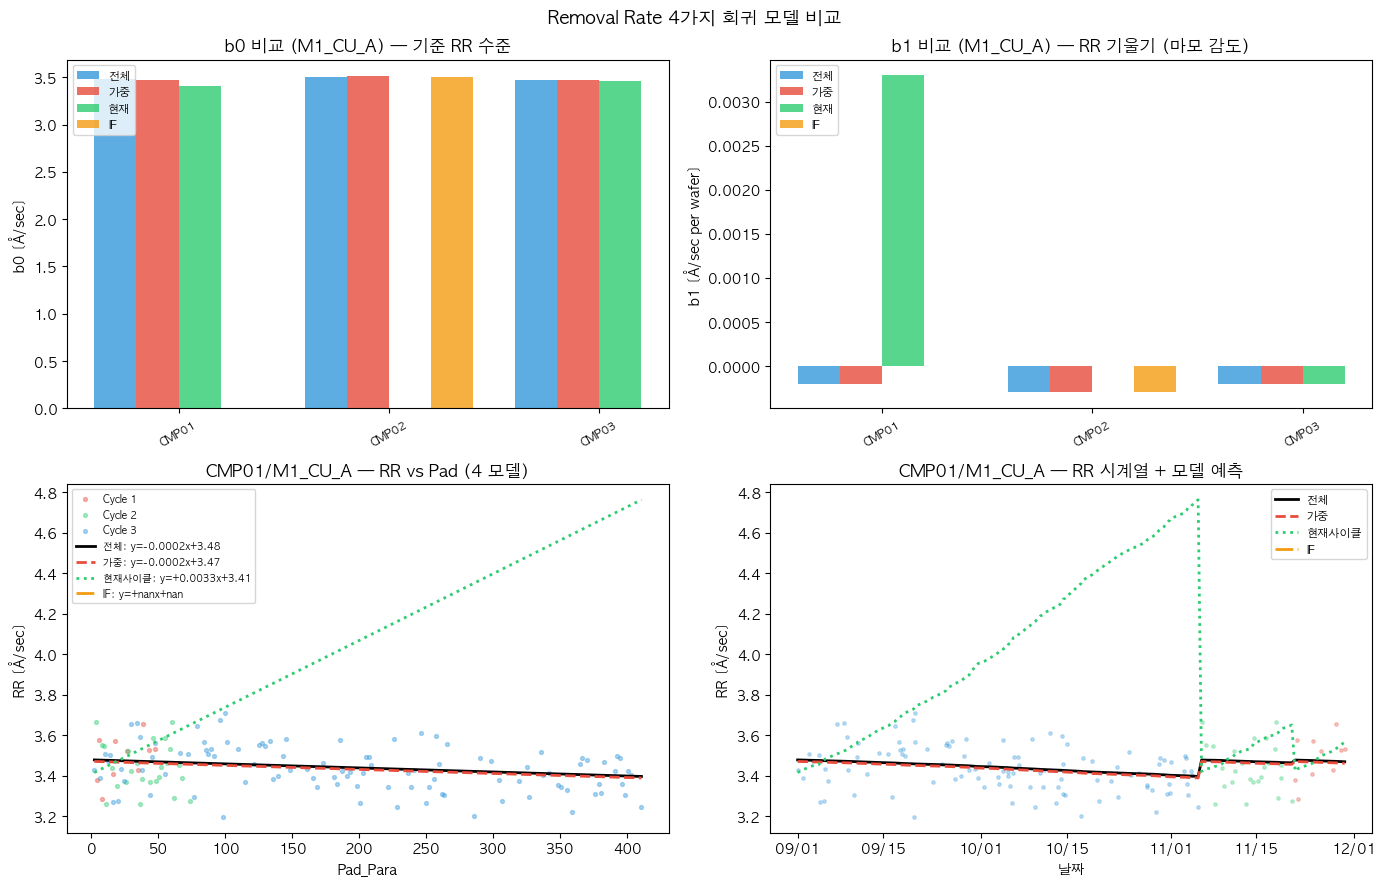

In [36]:
# ── 모델별 b0 트렌드 시각화 (장비별, b0 = 기준 RR 수준) ─────────────────
# b0 값이 클수록 패드 새것일 때 RR이 높음을 의미
target_recipe = 'M1_CU_A'
palette = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── (위 두 칸): 장비별 b0 비교 막대 ──
ax_b0 = axes[0, 0]
ax_b1 = axes[0, 1]

sub_df = rr_model_df[rr_model_df['Recipe'] == target_recipe].reset_index(drop=True)
x   = np.arange(len(sub_df))
w   = 0.2
labels = sub_df['EQ'].values

# b0 비교
model_pairs = [
    ('b0',          '전체',   '#3498db'),
    ('b0_weighted', '가중',   '#e74c3c'),
    ('b0_current',  '현재',   '#2ecc71'),
    ('if_b0',       'IF',     '#f39c12'),
]
for i, (col, name, color) in enumerate(model_pairs):
    vals = sub_df[col].astype(float)
    ax_b0.bar(x + (i-1.5)*w, vals, w, label=name, color=color, alpha=0.8)
ax_b0.set_xticks(x); ax_b0.set_xticklabels(labels, rotation=30, fontsize=8)
ax_b0.set_title(f'b0 비교 ({target_recipe}) — 기준 RR 수준')
ax_b0.set_ylabel('b0 [Å/sec]'); ax_b0.legend(fontsize=8)

# b1 비교
model_pairs_b1 = [
    ('b1',          '전체',   '#3498db'),
    ('b1_weighted', '가중',   '#e74c3c'),
    ('b1_current',  '현재',   '#2ecc71'),
    ('if_b1',       'IF',     '#f39c12'),
]
for i, (col, name, color) in enumerate(model_pairs_b1):
    vals = sub_df[col].astype(float)
    ax_b1.bar(x + (i-1.5)*w, vals, w, label=name, color=color, alpha=0.8)
ax_b1.set_xticks(x); ax_b1.set_xticklabels(labels, rotation=30, fontsize=8)
ax_b1.set_title(f'b1 비교 ({target_recipe}) — RR 기울기 (마모 감도)')
ax_b1.set_ylabel('b1 [Å/sec per wafer]'); ax_b1.legend(fontsize=8)

# ── (아래 두 칸): RR vs Pad_Para + 4 회귀선 (CMP01 / M1_CU_A) ──
target_eq = 'CMP01'
data_plot = merge_df_rr[
    (merge_df_rr['eqp_id'] == target_eq) & (merge_df_rr['recipe_id'] == target_recipe)
].sort_values('Pad_Para')

row = rr_model_df[(rr_model_df['EQ'] == target_eq) & (rr_model_df['Recipe'] == target_recipe)].iloc[0]
x_rng = np.linspace(data_plot['Pad_Para'].min(), data_plot['Pad_Para'].max(), 100)

ax_scatter = axes[1, 0]
for i, cycle in enumerate(sorted(data_plot['cycle'].unique())):
    sc = data_plot[data_plot['cycle'] == cycle]
    ax_scatter.scatter(sc['Pad_Para'], sc['RR'], s=8, alpha=0.4, color=palette[i % 4], label=f'Cycle {cycle}')

model_lines = [
    (row['b1'],          row['b0'],          '전체',    'black',  '-'),
    (row['b1_weighted'], row['b0_weighted'], '가중',    '#e74c3c', '--'),
    (row['b1_current'],  row['b0_current'],  '현재사이클','#2ecc71', ':'),
    (row['if_b1'],       row['if_b0'],       'IF',      '#f39c12', '-.'),
]
for b1v, b0v, name, color, ls in model_lines:
    if b1v is None: continue
    x_use = x_rng if name != 'IF' else x_rng[x_rng <= Pad_Seperation]
    ax_scatter.plot(x_use, float(b1v)*x_use + float(b0v), lw=2, color=color, linestyle=ls,
                    label=f'{name}: y={b1v:+.4f}x+{b0v:.2f}')

ax_scatter.set_xlabel('Pad_Para'); ax_scatter.set_ylabel('RR [Å/sec]')
ax_scatter.set_title(f'{target_eq}/{target_recipe} — RR vs Pad (4 모델)')
ax_scatter.legend(fontsize=7)

# ── RR 시계열 + 4 모델 예측 ──
ax_ts = axes[1, 1]
for i, cycle in enumerate(sorted(data_plot['cycle'].unique())):
    sc = data_plot[data_plot['cycle'] == cycle].sort_values('Date')
    ax_ts.scatter(sc['Date'], sc['RR'], s=6, alpha=0.3, color=palette[i % 4])

dp_s = data_plot.sort_values('Date')
for b1v, b0v, name, color, ls in model_lines:
    if b1v is None: continue
    pred = float(b1v) * dp_s['Pad_Para'] + float(b0v)
    ax_ts.plot(dp_s['Date'], pred, lw=2, color=color, linestyle=ls, label=name)

ax_ts.set_xlabel('날짜'); ax_ts.set_ylabel('RR [Å/sec]')
ax_ts.set_title(f'{target_eq}/{target_recipe} — RR 시계열 + 모델 예측')
ax_ts.legend(fontsize=8)
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.suptitle('Removal Rate 4가지 회귀 모델 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2-3 : 장비별 RR 트렌드

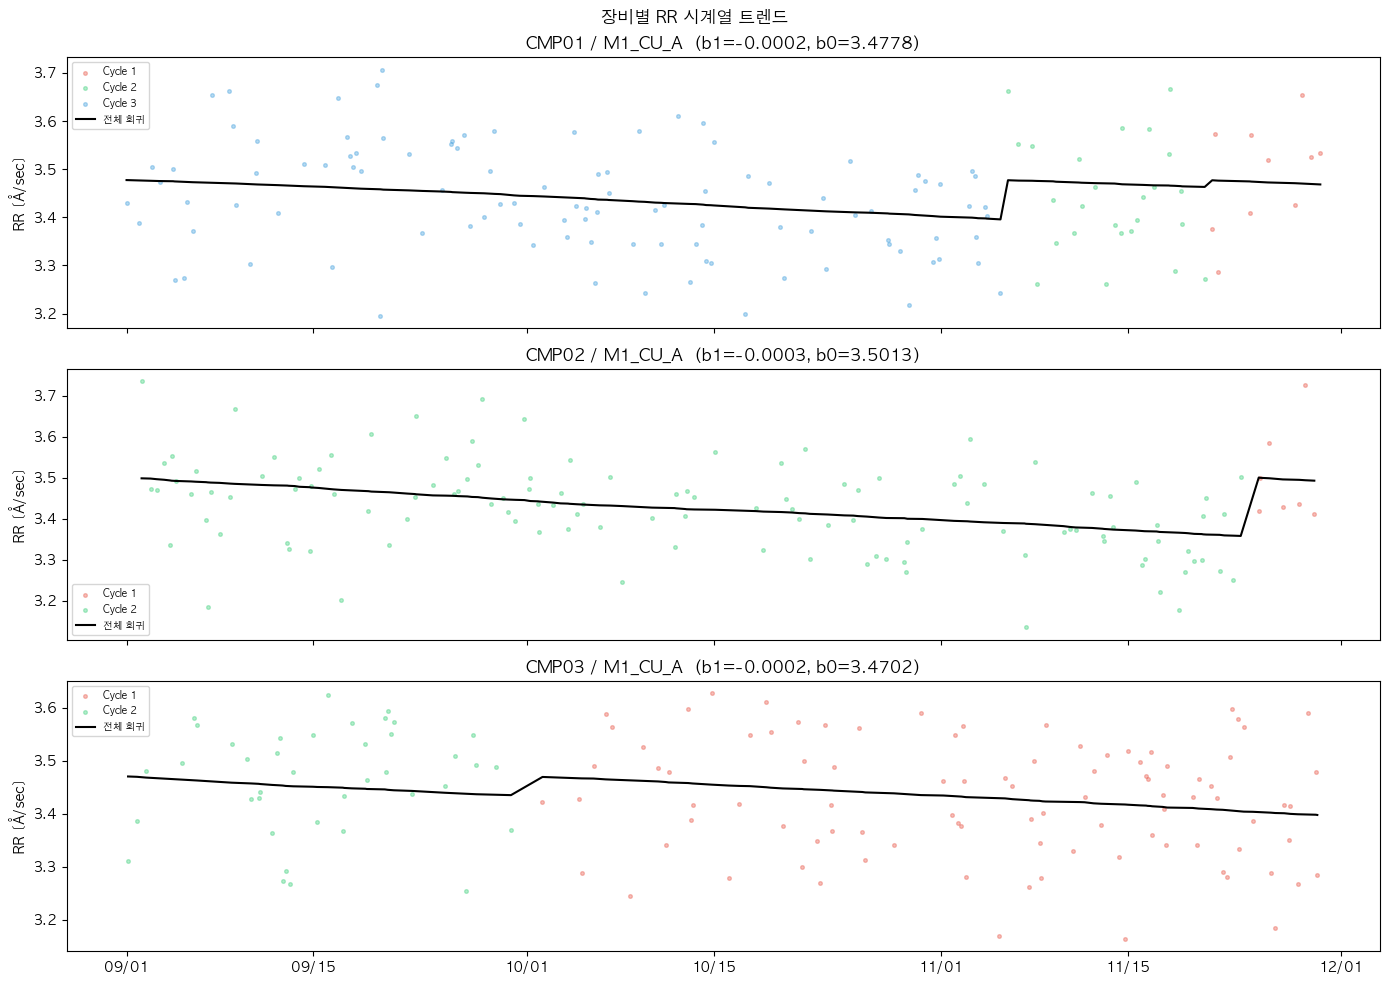

In [37]:
# 전체 장비 RR 시계열 비교
rr_results = rr_model_df[rr_model_df['Recipe'] == 'M1_CU_A'].set_index('EQ')[['b1','b0']].to_dict('index')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
pal = ['#e74c3c', '#2ecc71', '#3498db']

for ax_idx, eqp in enumerate(sorted(merge_df_rr['eqp_id'].unique())):
    ax   = axes[ax_idx]
    data = merge_df_rr[(merge_df_rr['eqp_id']==eqp) & (merge_df_rr['recipe_id']=='M1_CU_A')].sort_values('Date')
    if len(data) < 10 or eqp not in rr_results: continue

    b1v, b0v = rr_results[eqp]['b1'], rr_results[eqp]['b0']
    for i, cycle in enumerate(sorted(data['cycle'].unique())):
        sc = data[data['cycle'] == cycle]
        ax.scatter(sc['Date'], sc['RR'], s=7, alpha=0.35, color=pal[i % 3], label=f'Cycle {cycle}')

    ax.plot(data['Date'], float(b1v)*data['Pad_Para'] + float(b0v), lw=1.5, color='black', label='전체 회귀')
    ax.set_title(f'{eqp} / M1_CU_A  (b1={b1v:+.4f}, b0={b0v:.4f})')
    ax.set_ylabel('RR [Å/sec]')
    ax.legend(fontsize=7)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
fig.suptitle('장비별 RR 시계열 트렌드', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3 : Offset (연마시간 보정값)

### IDLE 조건 이해

IDLE 조건이란 CMP 장비 상태 또는 투입 순서를 구분한 것입니다.  
조건에 따라 패드 특성(수분·온도·컨디션)이 달라지므로 해당 wafer의 RR이 변합니다.

```
Idle_1 : 짧은 대기 후 재개 (≈1 slot 대기)   → 소폭 RR 변화
Idle_2 : 중간 대기 후 재개 (≈2 slot 대기)   → 중간 RR 변화
Idle_3 : 긴 대기   후 재개 (≈3 slot 대기)   → 큰 RR 변화
Idle_4 : 매우 긴 대기 후 재개 (≈4+slot)     → 더 큰 RR 변화

Layer_1 : Lot 내 1번째 층(레이어) wafer  → 레이어 순서별 편차 존재
Layer_2 : Lot 내 2번째 층 wafer
Layer_3 : Lot 내 3번째 층 wafer
Layer_4 : Lot 내 4번째 층 wafer

Normal ('') : 위 조건 해당 없음 → Offset 미적용
```

> **핵심 규칙**: `Idle_*` / `Layer_*` wafer에만 OFFSET 적용.  
> `Normal('')` wafer에는 Offset을 가산하지 않습니다.

### OFFSET 계산 공식
$$OFFSET = \frac{\Delta_{Target}}{RR_{실측}} - \frac{\Delta_{Target}}{RR_{패드모델}}$$

- **IDLE/Layer 조건 wafer에만 적용** — Normal wafer에는 Offset 미적용
- 조건별 평균 OFFSET을 학습하여 다음 동일 조건 wafer에 적용

In [38]:
# ── IDLE 조건 이해: 조건별 분포 확인 ───────────────────────────────────
print('=== IDLE 조건별 wafer 수 ===')
idle_dist = merge_df_rr['IDLE'].replace('', 'Normal').value_counts().sort_index().reset_index()
idle_dist.columns = ['IDLE', 'Count']
print(idle_dist.to_string(index=False))
print('\n→ Normal wafer       : Offset 미적용')
print('→ Idle_1~4 wafer     : 대기 조건별 평균 OFFSET 적용')
print('→ Layer_1~4 wafer    : 레이어 처리 순서별 평균 OFFSET 적용')

# 샘플: 실제 데이터에서 IDLE/Layer 조건이 포함된 wafer
print('\n=== IDLE/Layer 조건 wafer 샘플 ===')
idle_sample = merge_df_rr[merge_df_rr['IDLE'] != ''][[
    'Date', 'eqp_id', 'recipe_id', 'substrate_id', 'IDLE', 'RR'
]].head(12)
print(idle_sample.to_string(index=False))

=== IDLE 조건별 wafer 수 ===
   IDLE  Count
 Idle_1     58
 Idle_2     54
 Idle_3     49
 Idle_4     59
Layer_1     42
Layer_2     36
Layer_3     55
Layer_4     50
 Normal    397

→ Normal wafer       : Offset 미적용
→ Idle_1~4 wafer     : 대기 조건별 평균 OFFSET 적용
→ Layer_1~4 wafer    : 레이어 처리 순서별 평균 OFFSET 적용

=== IDLE/Layer 조건 wafer 샘플 ===
               Date eqp_id recipe_id substrate_id    IDLE       RR
2024-09-01 00:00:00  CMP01   M1_CU_A       W00000  Idle_4 3.429654
2024-09-01 21:36:00  CMP01   M1_CU_A       W00008  Idle_2 3.388258
2024-09-04 11:42:00  CMP01   M1_CU_A       W00031 Layer_3 3.501247
2024-09-05 06:36:00  CMP01   M1_CU_A       W00038 Layer_4 3.274376
2024-09-05 12:00:00  CMP01   M1_CU_A       W00040 Layer_2 3.431690
2024-09-05 22:48:00  CMP01   M1_CU_A       W00044 Layer_3 3.370930
2024-09-08 15:36:00  CMP01   M1_CU_A       W00068  Idle_2 3.661529
2024-09-08 23:42:00  CMP01   M1_CU_A       W00071 Layer_4 3.590592
2024-09-10 16:12:00  CMP01   M1_CU_A       W00086 Layer_3 3.49249

In [39]:
# ── OFFSET 산출 (IDLE 조건 wafer만) ──────────────────────────────────
# 실제 코드: OFFSET_Get.compute_offset()

offset_df = merge_df_rr.copy()

# RR 학습값(b1/b0) 적용
for eqp, vals in rr_results.items():
    mask = offset_df['eqp_id'] == eqp
    offset_df.loc[mask, 'RR_Pad'] = (
        offset_df.loc[mask, 'Pad_Para'] * float(vals['b1']) + float(vals['b0'])
    )

offset_df.dropna(subset=['RR_Pad', 'RR'], inplace=True)
offset_df = offset_df[offset_df['RR_Pad'].abs() > 0.1].copy()

delta = Pre_Target - Post_Target
offset_df['OFFSET'] = delta / offset_df['RR'] - delta / offset_df['RR_Pad']
offset_df['OFFSET'] = offset_df['OFFSET'].clip(-5, 3)

# ── IDLE 조건별 학습값 산출 ──────────────────────────────────────────
# Normal wafer는 OFFSET 산출에서 제외 (조건 해당 wafer만)
idle_only = offset_df[offset_df['IDLE'] != ''].copy()

idle_table = (
    idle_only
    .groupby(['eqp_id', 'recipe_id', 'IDLE'])['OFFSET']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'OFFSET_avg', 'std': 'OFFSET_std', 'count': 'Count'})
)

print('=== IDLE 조건별 OFFSET 학습값 ===')
print(idle_table.round(3).to_string(index=False))

print('\n=== Normal wafer에는 Offset 미적용 ===')
normal_offset = offset_df[offset_df['IDLE'] == '']['OFFSET']
print(f'Normal wafer OFFSET 분포: mean={normal_offset.mean():.3f}  std={normal_offset.std():.3f}')
print('(Normal wafer의 OFFSET은 참고용이며 실제 APC에 적용하지 않음)')

=== IDLE 조건별 OFFSET 학습값 ===
eqp_id recipe_id    IDLE  OFFSET_avg  OFFSET_std  Count
 CMP01   M1_CU_A  Idle_1       1.920       2.805      8
 CMP01   M1_CU_A  Idle_2      -0.066       3.701     10
 CMP01   M1_CU_A  Idle_3      -1.267       4.131     15
 CMP01   M1_CU_A  Idle_4      -2.000       4.140      8
 CMP01   M1_CU_A Layer_1       0.333       4.131      6
 CMP01   M1_CU_A Layer_2      -0.951       4.167     10
 CMP01   M1_CU_A Layer_3      -1.923       4.051     13
 CMP01   M1_CU_A Layer_4      -0.971       4.001      5
 CMP01   M1_CU_B  Idle_1      -0.920       4.139     10
 CMP01   M1_CU_B  Idle_2      -0.004       3.654     10
 CMP01   M1_CU_B  Idle_3      -1.478       3.741      9
 CMP01   M1_CU_B  Idle_4      -1.000       4.619      4
 CMP01   M1_CU_B Layer_1      -0.145       3.978      7
 CMP01   M1_CU_B Layer_2      -2.125       3.999      6
 CMP01   M1_CU_B Layer_3       0.000       4.140      8
 CMP01   M1_CU_B Layer_4      -1.000       4.276      8
 CMP02   M1_CU_A  Id

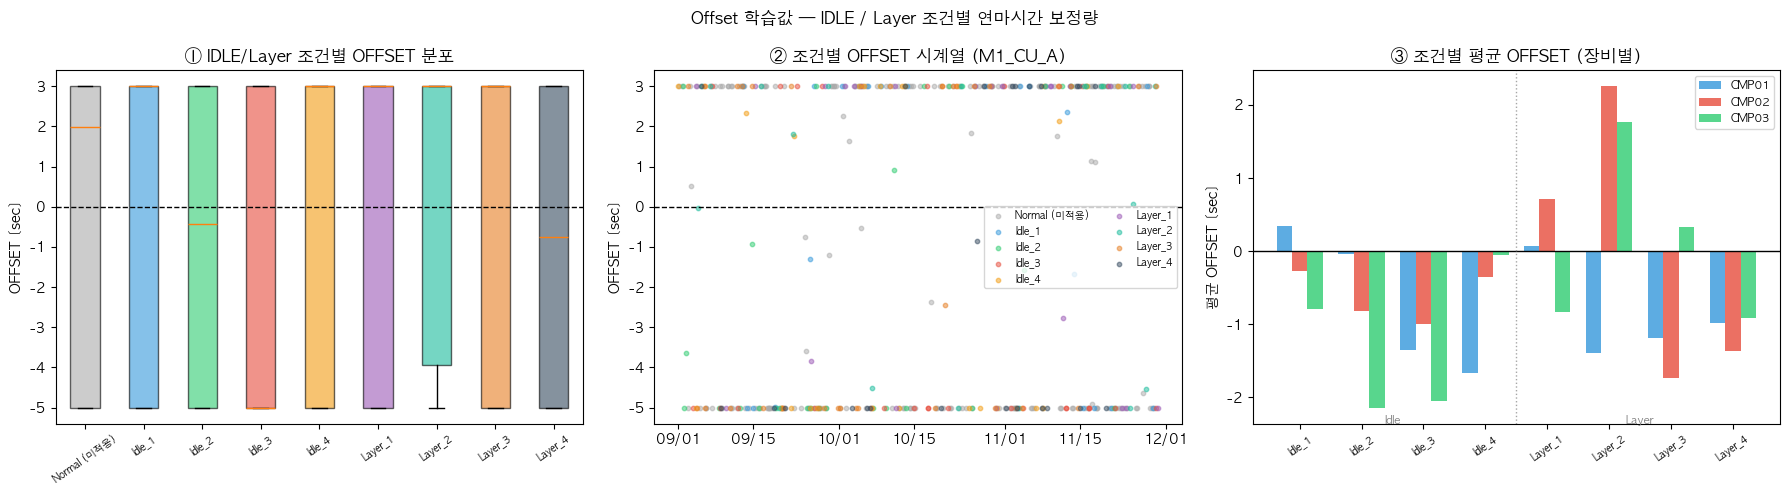


=== 실제 wafer APC 적용 예시 ===
wafer별 IDLE 조건 조회 → 해당 OFFSET 가산 (Normal은 0)

substrate_id eqp_id    IDLE    RR  RR_Pad  OFFSET_applied         적용여부
      W00223  CMP01         3.416   3.451           0.000   X (Normal)
      W00599  CMP02         3.136   3.388           0.000   X (Normal)
      W00154  CMP02         3.586   3.470           0.000   X (Normal)
      W00118  CMP01         3.512   3.465           0.000   X (Normal)
      W00600  CMP02         3.298   3.387           0.000   X (Normal)
      W00780  CMP03         3.267   3.399           0.000   X (Normal)
      W00672  CMP02  Idle_1 3.489   3.372          -0.294  O (IDLE 조건)
      W00617  CMP01 Layer_1 3.435   3.475           0.009 O (Layer 조건)
      W00469  CMP03 Layer_2 3.417   3.444           0.854 O (Layer 조건)
      W00449  CMP01 Layer_4 3.344   3.415          -1.460 O (Layer 조건)


In [40]:
# ── 시각화: IDLE/Layer 조건별 OFFSET 분포 + 시계열 ──────────────────────
idle_colors = {
    '':        ('#aaaaaa', 'Normal (미적용)'),
    'Idle_1':  ('#3498db', 'Idle_1'),
    'Idle_2':  ('#2ecc71', 'Idle_2'),
    'Idle_3':  ('#e74c3c', 'Idle_3'),
    'Idle_4':  ('#f39c12', 'Idle_4'),
    'Layer_1': ('#9b59b6', 'Layer_1'),
    'Layer_2': ('#1abc9c', 'Layer_2'),
    'Layer_3': ('#e67e22', 'Layer_3'),
    'Layer_4': ('#34495e', 'Layer_4'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ① 박스플롯: IDLE/Layer 조건별 OFFSET 분포 ──
ax = axes[0]
box_data, box_labels, box_colors = [], [], []
for idle_val, (color, label) in idle_colors.items():
    s = offset_df[offset_df['IDLE'] == idle_val]['OFFSET'].dropna()
    if len(s) > 0:
        box_data.append(s.values)
        box_labels.append(label)
        box_colors.append(color)

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_ylabel('OFFSET [sec]')
ax.set_title('① IDLE/Layer 조건별 OFFSET 분포')
ax.tick_params(axis='x', rotation=35, labelsize=7)

# ── ② 시계열: IDLE/Layer 조건별 OFFSET ──
ax2 = axes[1]
for idle_val, (color, label) in idle_colors.items():
    s = offset_df[(offset_df['IDLE'] == idle_val) & (offset_df['recipe_id'] == 'M1_CU_A')]
    if len(s) == 0: continue
    ax2.scatter(s['Date'], s['OFFSET'], s=10, alpha=0.5, color=color, label=label)

ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.set_ylabel('OFFSET [sec]')
ax2.set_title('② 조건별 OFFSET 시계열 (M1_CU_A)')
ax2.legend(fontsize=7, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# ── ③ 평균 OFFSET 막대 (장비별, IDLE/Layer 조건별) ──
ax3 = axes[2]
all_idle_vals = ['Idle_1', 'Idle_2', 'Idle_3', 'Idle_4',
                 'Layer_1', 'Layer_2', 'Layer_3', 'Layer_4']
eqps  = sorted(offset_df['eqp_id'].unique())
x_pos = np.arange(len(all_idle_vals))
width = 0.25
pal3  = ['#3498db', '#e74c3c', '#2ecc71']
for ei, eqp in enumerate(eqps):
    means = []
    for iv in all_idle_vals:
        s = offset_df[(offset_df['eqp_id']==eqp) & (offset_df['IDLE']==iv)]['OFFSET']
        means.append(s.mean() if len(s) > 0 else 0)
    ax3.bar(x_pos + (ei - 1) * width, means, width, label=eqp, color=pal3[ei], alpha=0.8)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(all_idle_vals, rotation=35, fontsize=7)
ax3.axhline(0, color='black', lw=1)
ax3.axvline(3.5, color='gray', lw=1, linestyle=':', alpha=0.7)  # Idle / Layer 구분선
ax3.text(1.5, ax3.get_ylim()[0] if ax3.get_ylim()[0] != 0 else -0.05,
         'Idle', ha='center', fontsize=8, color='gray')
ax3.text(5.5, ax3.get_ylim()[0] if ax3.get_ylim()[0] != 0 else -0.05,
         'Layer', ha='center', fontsize=8, color='gray')
ax3.set_ylabel('평균 OFFSET [sec]')
ax3.set_title('③ 조건별 평균 OFFSET (장비별)')
ax3.legend(fontsize=8)

plt.suptitle('Offset 학습값 — IDLE / Layer 조건별 연마시간 보정량', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 학습값 적용 예시 ─────────────────────────────────────────────────
print('\n=== 실제 wafer APC 적용 예시 ===')
print('wafer별 IDLE 조건 조회 → 해당 OFFSET 가산 (Normal은 0)')
print()

# IDLE/Layer 조건별 대표 OFFSET 값
idle_offset_map = (
    idle_table.groupby('IDLE')['OFFSET_avg'].mean().round(3).to_dict()
)
idle_offset_map[''] = 0.0  # Normal: Offset 없음

example = offset_df.sample(10, random_state=99)[['substrate_id', 'eqp_id', 'IDLE', 'RR', 'RR_Pad']].copy()
example['OFFSET_applied'] = example['IDLE'].map(idle_offset_map).fillna(0)
example['적용여부'] = example['IDLE'].apply(
    lambda x: 'O (IDLE 조건)' if x.startswith('Idle_') else
              'O (Layer 조건)' if x.startswith('Layer_') else
              'X (Normal)'
)
print(example.sort_values('IDLE').round(3).to_string(index=False))

---
## Part 4 : 전체 파이프라인 시뮬레이션

In [41]:
print('=' * 65)
print('  MICO 학습 파이프라인 시뮬레이션')
print('=' * 65)

# ─── STEP 1: Pre_Thk_VM ──────────────────────────────────────────
print('\n[STEP 1] Pre_Thk_VM 계산')
df_s1 = merge_df.copy()
df_s1['BIAS'] = df_s1['Pre_THK_ITM'] - df_s1['Pre_THK_ITM'].mean()
df_s1 = iqr_filter(df_s1, 'BIAS', sigma=3)
df_s1 = rolling_mean_by_ch(df_s1, 'BIAS', period='30D', min_count=10)

ma_result = (
    df_s1.dropna(subset=['Pre_Thk'])
    .sort_values('pre_oper_time')
    .groupby('pre_eq_ch').last()[['Pre_Thk', 'Pre_Thk_Count']]
    .reset_index()
)
print(f'  → MA 학습: {len(ma_result)}개 chamber  |  PRE_OPER2 b1={b1_oper2:+.4f}  b0={b0_oper2:+.4f}')
for _, r in ma_result.iterrows():
    print(f'     {r["pre_eq_ch"]:12s}  Pre_Thk_MA={r["Pre_Thk"]:+7.2f} Å  Count={int(r["Pre_Thk_Count"])}')

# ─── STEP 2: Removal Rate ─────────────────────────────────────────
print('\n[STEP 2] Removal Rate 계산')
for _, row in rr_model_df.iterrows():
    current_str = f'  b1_current={row["b1_current"]:+.4f} b0_current={row["b0_current"]:.4f}' \
                  if row['b1_current'] is not None else '  (current: 데이터 부족)'
    if_str = f'  if_b1={row["if_b1"]:+.4f}' if row['if_b1'] is not None else ''
    print(f'  → {row["EQ"]}/{row["Recipe"]}:  b1={row["b1"]:+.4f} b0={row["b0"]:.4f}')
    print(f'     가중: b1_w={row["b1_weighted"]:+.4f} b0_w={row["b0_weighted"]:.4f}{current_str}{if_str}')

# ─── STEP 3: Offset ───────────────────────────────────────────────
print('\n[STEP 3] Offset 계산 (IDLE / Layer 조건 wafer에만 적용)')
for idle_val, avg_offset in sorted(idle_offset_map.items()):
    label = 'Normal' if idle_val == '' else idle_val
    apply = 'X (미적용)' if idle_val == '' else 'O (적용)'
    cnt   = len(offset_df[offset_df['IDLE'] == idle_val])
    print(f'  {label:10s}: OFFSET={avg_offset:+.3f} sec  ({apply})  n={cnt}')

print('\n' + '=' * 65)
print('  학습 파이프라인 완료')
print('=' * 65)

  MICO 학습 파이프라인 시뮬레이션

[STEP 1] Pre_Thk_VM 계산
  → MA 학습: 8개 chamber  |  PRE_OPER2 b1=+2.6125  b0=-18.7764
     DEP01_A       Pre_Thk_MA= -43.87 Å  Count=34
     DEP01_B       Pre_Thk_MA= -50.70 Å  Count=37
     DEP02_A       Pre_Thk_MA= +32.76 Å  Count=37
     DEP02_B       Pre_Thk_MA= +53.52 Å  Count=37
     DEP03_A       Pre_Thk_MA= +20.68 Å  Count=35
     DEP03_B       Pre_Thk_MA=  +9.77 Å  Count=23
     DEP04_A       Pre_Thk_MA= -23.07 Å  Count=33
     DEP04_B       Pre_Thk_MA= +17.80 Å  Count=35

[STEP 2] Removal Rate 계산
  → CMP01/M1_CU_A:  b1=-0.0002 b0=3.4778
     가중: b1_w=-0.0002 b0_w=3.4703  b1_current=+0.0033 b0_current=3.4081  if_b1=+nan
  → CMP01/M1_CU_B:  b1=-0.0003 b0=3.4930
     가중: b1_w=-0.0004 b0_w=3.5084  b1_current=+0.0007 b0_current=3.4741  if_b1=+nan
  → CMP02/M1_CU_A:  b1=-0.0003 b0=3.5013
     가중: b1_w=-0.0003 b0_w=3.5112  b1_current=+nan b0_current=nan  if_b1=-0.0003
  → CMP02/M1_CU_B:  b1=-0.0003 b0=3.4768
     가중: b1_w=-0.0003 b0_w=3.4759  b1_current=+0.0026 b

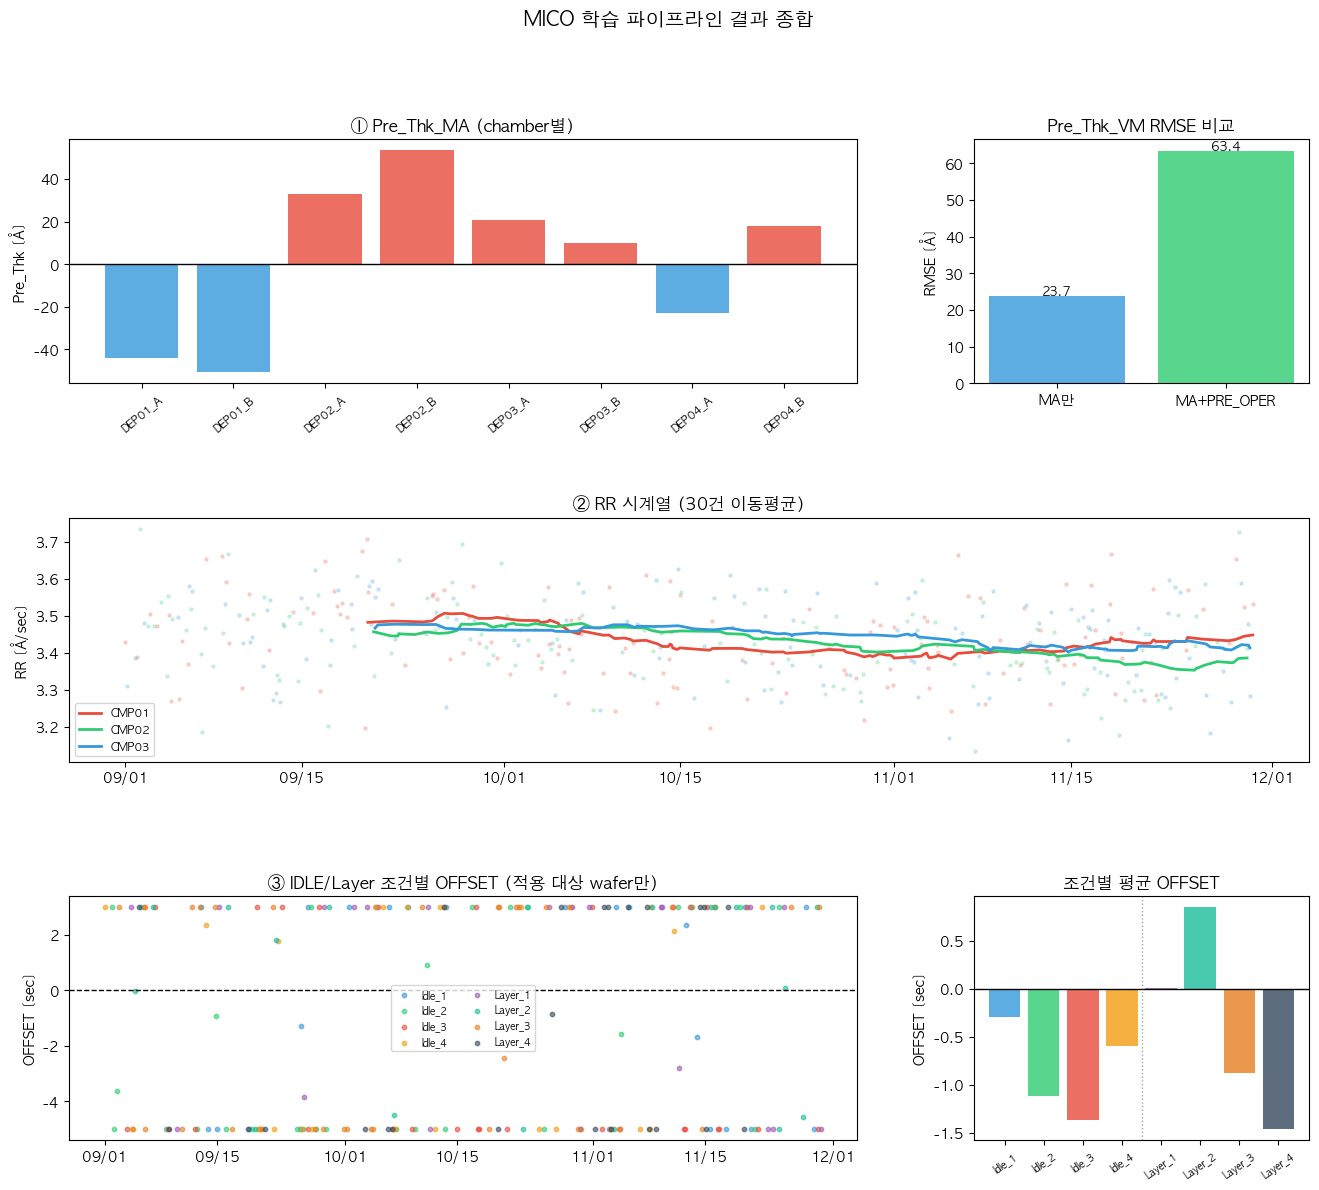

In [42]:
# ── 파이프라인 결과 종합 시각화 ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 13))
gs  = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# (0,:2) Pre_Thk_VM 막대
ax_vm = fig.add_subplot(gs[0, :2])
c_bar = ['#e74c3c' if v > 0 else '#3498db' for v in ma_result['Pre_Thk']]
ax_vm.bar(ma_result['pre_eq_ch'], ma_result['Pre_Thk'], color=c_bar, alpha=0.8)
ax_vm.axhline(0, color='black', lw=1)
ax_vm.set_title('① Pre_Thk_MA (chamber별)')
ax_vm.set_ylabel('Pre_Thk [Å]')
ax_vm.tick_params(axis='x', rotation=40, labelsize=8)

# (0,2) PRE_OPER 회귀 효과
ax_vm2 = fig.add_subplot(gs[0, 2])
ax_vm2.bar(['MA만', 'MA+PRE_OPER'], [rmse_ma, rmse_vm], color=['#3498db','#2ecc71'], alpha=0.8)
ax_vm2.set_title('Pre_Thk_VM RMSE 비교')
ax_vm2.set_ylabel('RMSE [Å]')
for i, v in enumerate([rmse_ma, rmse_vm]):
    ax_vm2.text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

# (1,:) RR 트렌드
ax_rr = fig.add_subplot(gs[1, :])
pal_rr = ['#e74c3c', '#2ecc71', '#3498db']
for i, eqp in enumerate(sorted(merge_df_rr['eqp_id'].unique())):
    s = merge_df_rr[(merge_df_rr['eqp_id']==eqp) & (merge_df_rr['recipe_id']=='M1_CU_A')].sort_values('Date')
    ax_rr.scatter(s['Date'], s['RR'], s=5, alpha=0.2, color=pal_rr[i])
    ax_rr.plot(s['Date'], s['RR'].rolling(30).mean(), lw=2, color=pal_rr[i], label=eqp)
ax_rr.set_title('② RR 시계열 (30건 이동평균)')
ax_rr.set_ylabel('RR [Å/sec]')
ax_rr.legend(fontsize=8)
ax_rr.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# (2,:2) Offset 시계열 (IDLE + Layer 조건, Normal 제외)
ax_off = fig.add_subplot(gs[2, :2])
for idle_val, (color, label) in idle_colors.items():
    if idle_val == '': continue
    s = offset_df[(offset_df['IDLE']==idle_val) & (offset_df['recipe_id']=='M1_CU_A')]
    if len(s): ax_off.scatter(s['Date'], s['OFFSET'], s=10, alpha=0.6, color=color, label=label)
ax_off.axhline(0, color='black', lw=1, linestyle='--')
ax_off.set_title('③ IDLE/Layer 조건별 OFFSET (적용 대상 wafer만)')
ax_off.set_ylabel('OFFSET [sec]')
ax_off.legend(fontsize=7, ncol=2)
ax_off.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# (2,2) 평균 OFFSET 막대 (Idle + Layer 전체)
ax_ov = fig.add_subplot(gs[2, 2])
idle_labels2 = sorted([k for k in idle_offset_map if k != ''])
idle_means2  = [idle_offset_map[k] for k in idle_labels2]
c_idle = ['#3498db','#2ecc71','#e74c3c','#f39c12',
          '#9b59b6','#1abc9c','#e67e22','#34495e']
ax_ov.bar(idle_labels2, idle_means2, color=c_idle[:len(idle_labels2)], alpha=0.8)
ax_ov.axhline(0, color='black', lw=1)
ax_ov.axvline(3.5, color='gray', lw=1, linestyle=':', alpha=0.7)
ax_ov.set_title('조건별 평균 OFFSET')
ax_ov.set_ylabel('OFFSET [sec]')
ax_ov.tick_params(axis='x', rotation=35, labelsize=7)

fig.suptitle('MICO 학습 파이프라인 결과 종합', fontsize=14, fontweight='bold')
plt.show()

---
## 실습 문제

### Q1. Pre_Thk_VM
- `period='30D'` → `'60D'` 로 바꾸면 Rolling Mean이 어떻게 달라지나요?
- `b1_oper2`와 설정값(0.35)의 오차는 몇 % 인가요?
- PRE_OPER 보정 전(MA만)과 후(VM)의 RMSE 개선율은?

### Q2. Removal Rate
- `b1_weighted`과 `b1` 의 차이: 최근 구간이 전체 구간보다 RR 경향이 다른가요?
- `RR_Weight = 5` → `20`으로 바꾸면 `b1_weighted`가 어떻게 변하나요?
- 현재 사이클(cycle=1)의 데이터가 `RR_Count(10)` 미만이면 어떻게 처리되나요?

### Q3. Offset
- Idle_1과 Idle_4의 평균 OFFSET 차이는 몇 초인가요?
- Normal wafer에 Offset을 적용하면 어떤 문제가 생기나요?
- `OFFSET.clip(-5, 3)` 범위를 넓히면 어떤 데이터가 영향을 받나요?

In [ ]:
# ── 실습 공간 ─────────────────────────────────────────────────────────

# 예시 1: PRE_OPER 보정 효과
print('=== Q1 힌트: Pre_Thk_VM 개선율 ===')
improvement = (rmse_ma - rmse_vm) / rmse_ma * 100
print(f'  RMSE 개선: {rmse_ma:.2f} → {rmse_vm:.2f} Å  ({improvement:.1f}% 개선)')
print(f'  b1_oper2 학습값={b1_oper2:.4f}  설정값=0.35  오차={(abs(b1_oper2-0.35)/0.35*100):.1f}%')

# 예시 2: Idle 조건별 평균 OFFSET
print('\n=== Q3 힌트: IDLE별 평균 OFFSET ===')
for k, v in sorted(idle_offset_map.items()):
    label = 'Normal (미적용)' if k == '' else k
    print(f'  {label:20s}: {v:+.3f} sec')

idle_vals_only = {k: v for k, v in idle_offset_map.items() if k != ''}
if idle_vals_only:
    max_k = max(idle_vals_only, key=idle_vals_only.get)
    min_k = min(idle_vals_only, key=idle_vals_only.get)
    diff  = idle_vals_only[max_k] - idle_vals_only[min_k]
    print(f'\n  최대-최소 차이: {max_k}({idle_vals_only[max_k]:+.3f}) - {min_k}({idle_vals_only[min_k]:+.3f}) = {diff:.3f} sec')

print('\n\n── 여기서부터 실습 코드를 작성하세요 ────────────────────────────')
# 여기에 실습 코드를 작성하세요
